
Segmentation Lead: Diabetes Risk Clustering

K-Means clustering with k=3 to identify lifestyle personas


In [11]:
#Import Libraries
import pandas as pd                    
import seaborn as sns                  
import matplotlib.pyplot as plt        
from sklearn.preprocessing import StandardScaler   
from sklearn.cluster import KMeans                
from sklearn.decomposition import PCA              
import os

Load Dataset (with robust path handling)

In [16]:
# For Jupyter notebook - get the current directory
import os
script_dir = os.getcwd()  # Gets current working directory (the notebook's folder)
# Go up one level to project root, then into data folder
data_path = os.path.join(script_dir, '..', 'data', 'Diabetes_and_LifeStyle_Dataset_.csv')
df = pd.read_csv(data_path)

print("First 5 rows of the dataset:")
print(df.head())
print("\nDataset shape:", df.shape)

First 5 rows of the dataset:
   Age  gender ethnicity education_level  income_level employment_status  \
0   58    Male     Asian      Highschool  Lower-Middle          Employed   
1   52  Female     White      Highschool        Middle          Employed   
2   60    Male  Hispanic      Highschool        Middle        Unemployed   
3   74  Female     Black      Highschool           Low           Retired   
4   46    Male     White        Graduate        Middle           Retired   

  smoking_status  alcohol_consumption_per_week  \
0          Never                             0   
1         Former                             1   
2          Never                             1   
3          Never                             0   
4          Never                             1   

   physical_activity_minutes_per_week  diet_score  ...  hdl_cholesterol  \
0                                 215         5.7  ...               41   
1                                 143         6.7  ...         

Select Lifestyle Features for Clustering

In [18]:
features = [
    'physical_activity_minutes_per_week',   
    'diet_score',                           
    'sleep_hours_per_day',                  
    'bmi',                                  
    'alcohol_consumption_per_week'          
]

print("\nLifestyle features (first 5 rows):")
print(df[features].head())


Lifestyle features (first 5 rows):
   physical_activity_minutes_per_week  diet_score  sleep_hours_per_day   bmi  \
0                                 215         5.7                  7.9  30.5   
1                                 143         6.7                  6.5  23.1   
2                                  57         6.4                 10.0  22.2   
3                                  49         3.4                  6.6  26.8   
4                                 109         7.2                  7.4  21.2   

   alcohol_consumption_per_week  
0                             0  
1                             1  
2                             1  
3                             0  
4                             1  


In [19]:
#Scale the Features (Important for K-Means)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

print("\nAfter scaling (first 5 rows):")
print(X_scaled[:5])


After scaling (first 5 rows):
[[ 1.13755831 -0.16584226  0.82497514  1.36131716 -1.41358823]
 [ 0.28489686  0.39592808 -0.45505977 -0.70090161 -0.70839588]
 [-0.73355988  0.22739698  2.7450275  -0.951712   -0.70839588]
 [-0.82830004 -1.45791404 -0.3636287   0.33020778 -1.41358823]
 [-0.11774883  0.67681325  0.36781981 -1.23039022 -0.70839588]]


In [20]:
#Run K-Means Clustering with k=3

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Lifestyle_Segment'] = kmeans.fit_predict(X_scaled)

print("\nNumber of people in each cluster:")
print(df['Lifestyle_Segment'].value_counts())


Number of people in each cluster:
Lifestyle_Segment
1    39649
2    39460
0    18188
Name: count, dtype: int64


In [21]:
#Assign Meaningful Persona Names


persona_map = {
    0: 'The Active Movers',
    1: 'The High-Risk Inactive',
    2: 'The Mindful Eaters'
}
df['Persona'] = df['Lifestyle_Segment'].map(persona_map)

print("\nFirst 10 rows with Persona assigned:")
print(df[['Lifestyle_Segment', 'Persona'] + features].head(10))


First 10 rows with Persona assigned:
   Lifestyle_Segment                 Persona  \
0                  0       The Active Movers   
1                  2      The Mindful Eaters   
2                  2      The Mindful Eaters   
3                  1  The High-Risk Inactive   
4                  2      The Mindful Eaters   
5                  2      The Mindful Eaters   
6                  2      The Mindful Eaters   
7                  1  The High-Risk Inactive   
8                  2      The Mindful Eaters   
9                  2      The Mindful Eaters   

   physical_activity_minutes_per_week  diet_score  sleep_hours_per_day   bmi  \
0                                 215         5.7                  7.9  30.5   
1                                 143         6.7                  6.5  23.1   
2                                  57         6.4                 10.0  22.2   
3                                  49         3.4                  6.6  26.8   
4                                

In [22]:
# PCA for 2D Visualisation


pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)
df['PC1'] = pca_results[:, 0]
df['PC2'] = pca_results[:, 1]

print(f"\nPC1 explains: {pca.explained_variance_ratio_[0] * 100:.2f}%")
print(f"PC2 explains: {pca.explained_variance_ratio_[1] * 100:.2f}%")
print(f"Total variance explained: {(pca.explained_variance_ratio_.sum() * 100):.2f}%")


PC1 explains: 24.26%
PC2 explains: 20.14%
Total variance explained: 44.40%


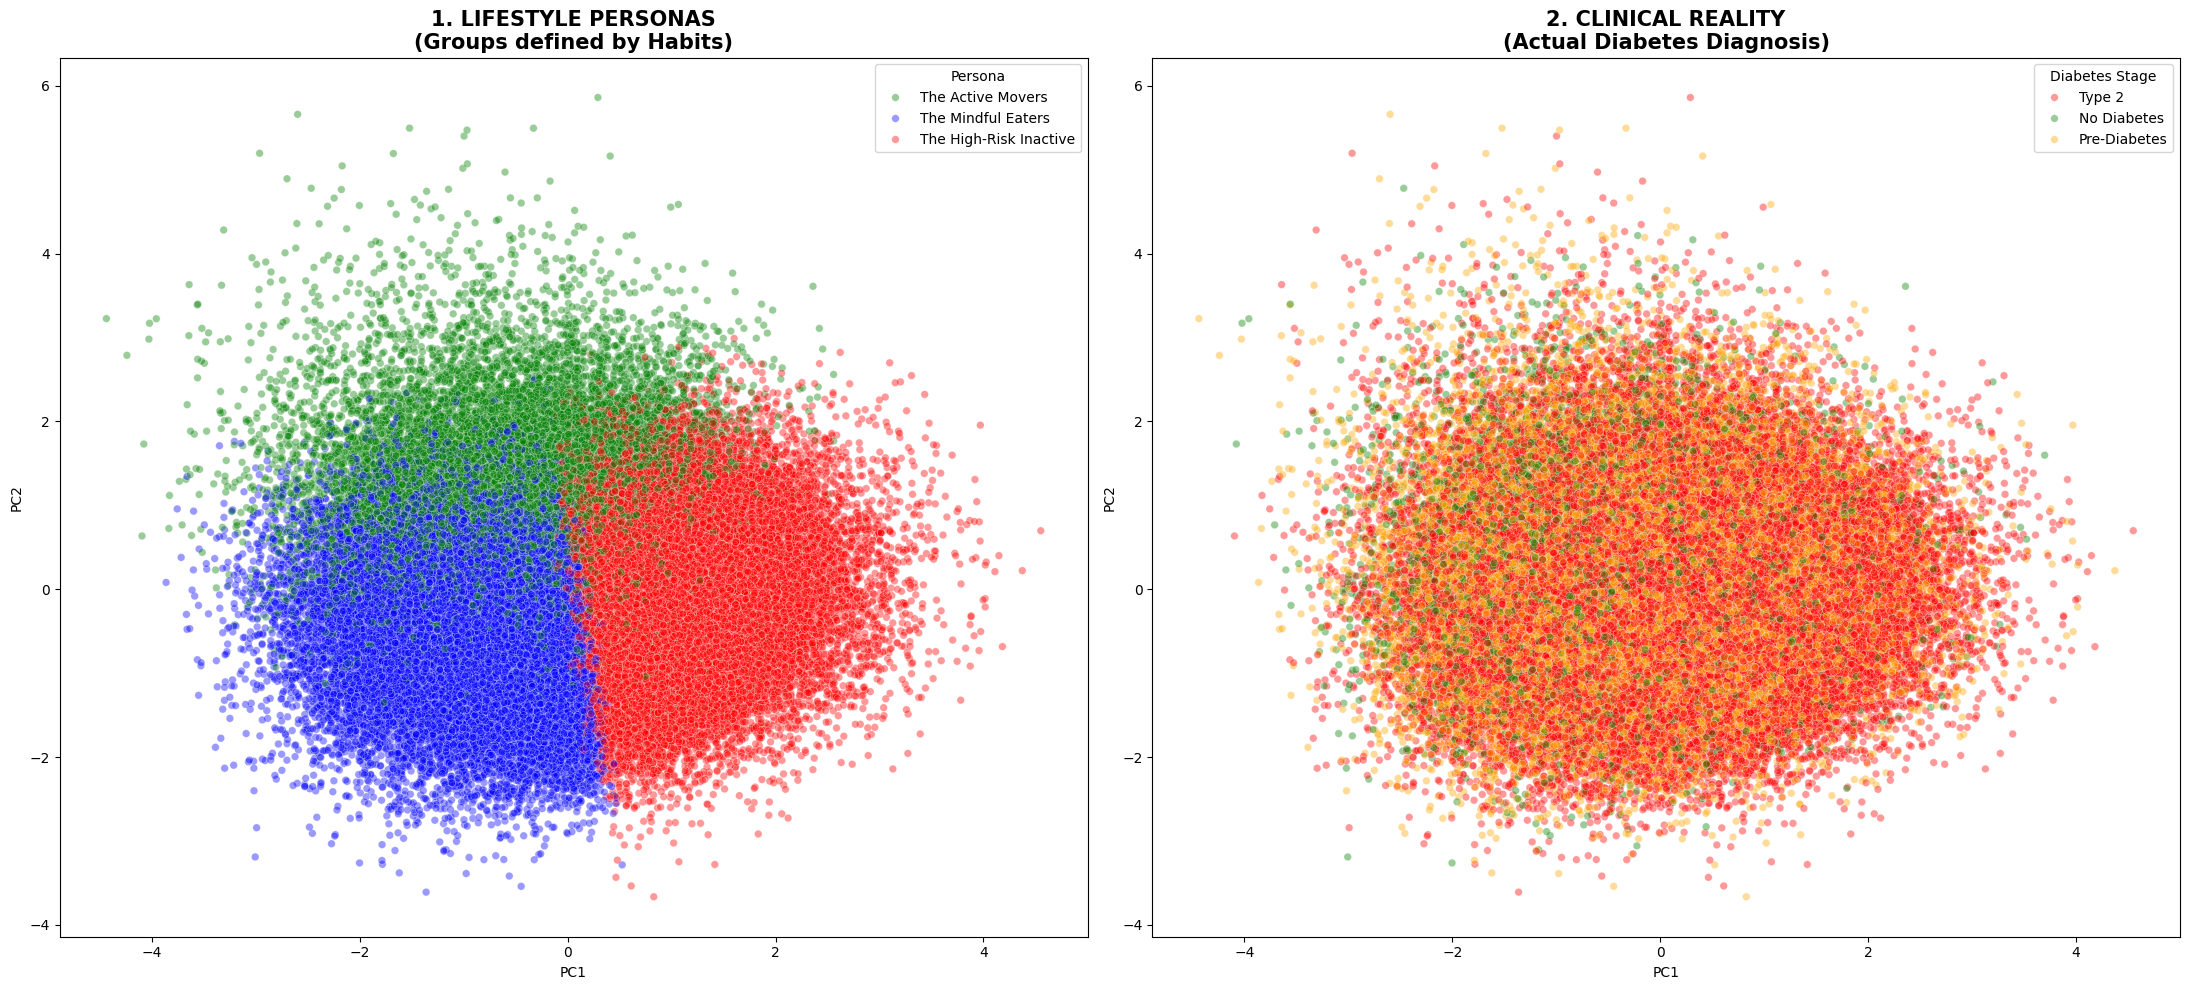

In [23]:
#Visualisation: Personas vs Clinical Reality

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

persona_colors = {
    'The Active Movers': 'green',
    'The High-Risk Inactive': 'red',
    'The Mindful Eaters': 'blue'
}

disease_colors = {
    'No Diabetes': 'green',
    'Pre-Diabetes': 'orange',
    'Type 2': 'red'
}

# Graph A: Lifestyle Personas
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Persona', 
                palette=persona_colors, alpha=0.4, s=30, ax=axes[0])
axes[0].set_title("1. LIFESTYLE PERSONAS\n(Groups defined by Habits)", fontsize=15, fontweight='bold')
axes[0].legend(title="Persona")

# Graph B: Reality
target_stages = ['No Diabetes', 'Pre-Diabetes', 'Type 2']
df_filtered = df[df['diabetes_stage'].isin(target_stages)]
sns.scatterplot(data=df_filtered, x='PC1', y='PC2', hue='diabetes_stage', 
                palette=disease_colors, alpha=0.4, s=30, ax=axes[1])
axes[1].set_title("2. CLINICAL REALITY\n(Actual Diabetes Diagnosis)", fontsize=15, fontweight='bold')
axes[1].legend(title="Diabetes Stage")

plt.tight_layout()
plt.show()

In [25]:
#Risk Analysis: Two Views


# Row percentages (within each persona)
row_table = pd.crosstab(df['Persona'], df['diabetes_stage'], normalize='index') * 100
print("\n" + "="*60)
print("VIEW 1: WITHIN EACH PERSONA – what % has each diabetes stage?")
print("(Each row sums to 100%)")
print("="*60)
print(row_table[['No Diabetes', 'Pre-Diabetes', 'Type 2']].round(2))

# Column percentages (within each diabetes stage)
col_table = pd.crosstab(df['Persona'], df['diabetes_stage'], normalize='columns') * 100
print("\n" + "="*60)
print("VIEW 2: TOTAL POPULATION SPREAD – for each diabetes stage, what % are in each Persona?")
print("(Each column sums to 100%)")
print("="*60)
print(col_table[['No Diabetes', 'Pre-Diabetes', 'Type 2']].round(2))

print("\n" + "🔴"*30)
print("KEY INSIGHT: Distribution of Type 2 patients across personas")
print("🔴"*30)
type2_distribution = col_table['Type 2'].sort_values(ascending=False)
for persona, pct in type2_distribution.items():
    print(f"   {persona}: {pct:.1f}%")


VIEW 1: WITHIN EACH PERSONA – what % has each diabetes stage?
(Each row sums to 100%)
diabetes_stage          No Diabetes  Pre-Diabetes  Type 2
Persona                                                  
The Active Movers             12.40         35.86   51.35
The High-Risk Inactive         5.47         28.94   65.25
The Mindful Eaters             8.40         32.99   58.17

VIEW 2: TOTAL POPULATION SPREAD – for each diabetes stage, what % are in each Persona?
(Each column sums to 100%)
diabetes_stage          No Diabetes  Pre-Diabetes  Type 2
Persona                                                  
The Active Movers             29.15         21.03   16.06
The High-Risk Inactive        28.02         36.99   44.48
The Mindful Eaters            42.83         41.97   39.46

🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴
KEY INSIGHT: Distribution of Type 2 patients across personas
🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴
   The High-Risk Inactive: 44.5%
   The Mindful Eaters: 39.5%
   The Active Movers: 16.1%


In [26]:
#Cluster Profiles (Average Values per Persona)

print("\n" + "="*60)
print("CLUSTER PROFILES (average lifestyle values per persona)")
print("="*60)
print(df.groupby('Persona')[features].mean().round(1))


CLUSTER PROFILES (average lifestyle values per persona)
                        physical_activity_minutes_per_week  diet_score  \
Persona                                                                  
The Active Movers                                    254.4         5.9   
The High-Risk Inactive                                87.5         4.8   
The Mindful Eaters                                    88.1         7.2   

                        sleep_hours_per_day   bmi  \
Persona                                             
The Active Movers                       7.0  24.9   
The High-Risk Inactive                  7.0  28.0   
The Mindful Eaters                      7.0  23.5   

                        alcohol_consumption_per_week  
Persona                                               
The Active Movers                                2.0  
The High-Risk Inactive                           2.0  
The Mindful Eaters                               2.0  


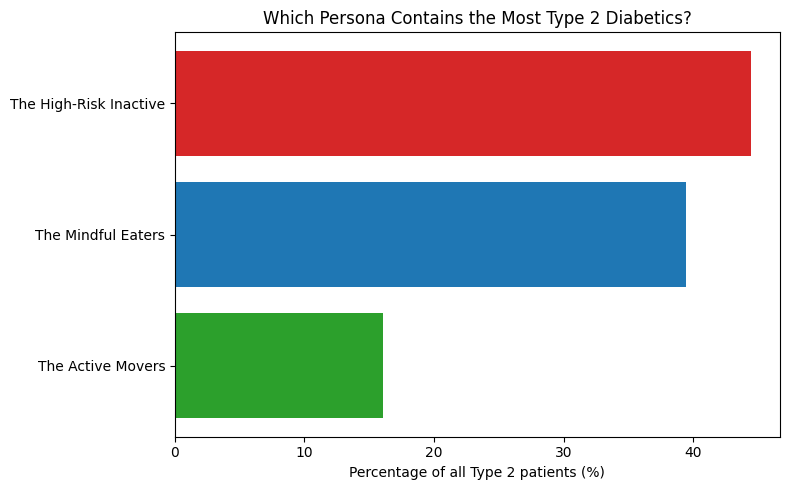

In [27]:
#Additional Bar Chart of Type 2 Capture Rates

plt.figure(figsize=(8, 5))
type2_capture = col_table['Type 2'].sort_values()
colors = ['#2ca02c', '#1f77b4', '#d62728']
plt.barh(type2_capture.index, type2_capture.values, color=colors)
plt.xlabel('Percentage of all Type 2 patients (%)')
plt.title('Which Persona Contains the Most Type 2 Diabetics?')
plt.tight_layout()
plt.show()

In [28]:
#Save Results (Optional – commented out)


# df.to_csv('../artifacts/segmented_patients.csv', index=False)
# print("\n✓ Saved segmented dataset to '../artifacts/segmented_patients.csv'")
# cluster_profiles = df.groupby('Persona')[features].mean()
# cluster_profiles.to_csv('../artifacts/cluster_profiles.csv')
# print("✓ Saved cluster profiles to '../artifacts/cluster_profiles.csv'")

print("\n" + "="*60)
print("SEGMENTATION COMPLETE!! - Your personas are ready!")
print("="*60)


SEGMENTATION COMPLETE!! - Your personas are ready!
